# 04 — Logistic Regression

Train a logistic regression classifier with class-weight balancing and evaluate fraud-appropriate metrics.

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import load_processed,load_processed_sm
from src.model_training import train_logistic_regression,train_logistic_regression_sm
from src.evaluation import evaluate_model
from src.visualization import plot_confusion_matrix, plot_roc_curves, plot_pr_curves

In [22]:
X_train, X_test, y_train, y_test = load_processed()

## Train

In [23]:
model = train_logistic_regression(X_train, y_train)
print('Training complete.')

Model saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../models/logistic_regression.pkl
Training complete.


# Train on Synthetic Data

In [24]:
X_train_sm, y_train_sm = load_processed_sm()


In [25]:
model_sm = train_logistic_regression_sm(X_train=X_train_sm,y_train=y_train_sm)
print("Training complete")

Training complete


## Evaluate


Model: logistic_regression
ROC-AUC: 0.9722  |  AUPRC: 0.7189
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/confusion_matrices/logistic_regression.png


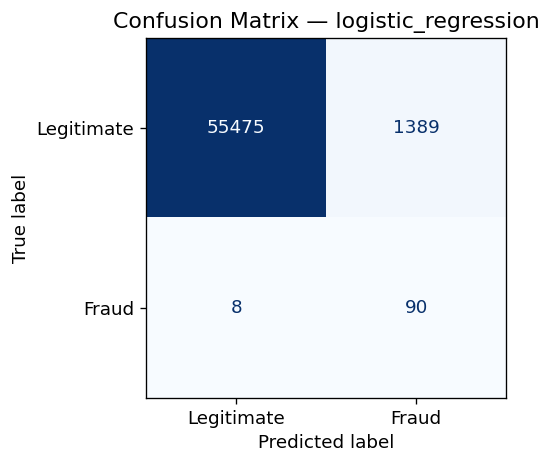

In [26]:
result = evaluate_model(model, X_test, y_test, 'logistic_regression')
plot_confusion_matrix(result['confusion_matrix'], 'logistic_regression')

# Evaluate Model Trained on Synthetic Data


Model: logistic_regression_sm
ROC-AUC: 0.9698  |  AUPRC: 0.7249
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/confusion_matrices/logistic_regression_sm.png


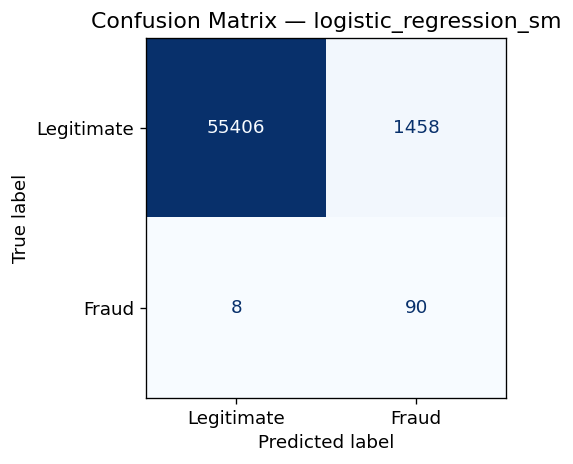

In [27]:
result_sm = evaluate_model(model_sm, X_test, y_test, 'logistic_regression_sm')
plot_confusion_matrix(result_sm['confusion_matrix'], 'logistic_regression_sm')

## Threshold Analysis

Default threshold is 0.5. Lowering it increases recall (catches more fraud) but increases false positives.

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
rows = []
for t in thresholds:
    y_pred_t = (result['y_proba'] >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
    })
pd.DataFrame(rows)

,threshold,precision,recall,f1
0,0.1,0.008120,0.948980,0.016103
1,0.2,0.016358,0.938776,0.032157
2,0.3,0.027314,0.918367,0.053050
3,0.4,0.042135,0.918367,0.080573
4,0.5,0.060852,0.918367,0.114141


Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/roc_curves/roc_comparison_logistic_regression.png


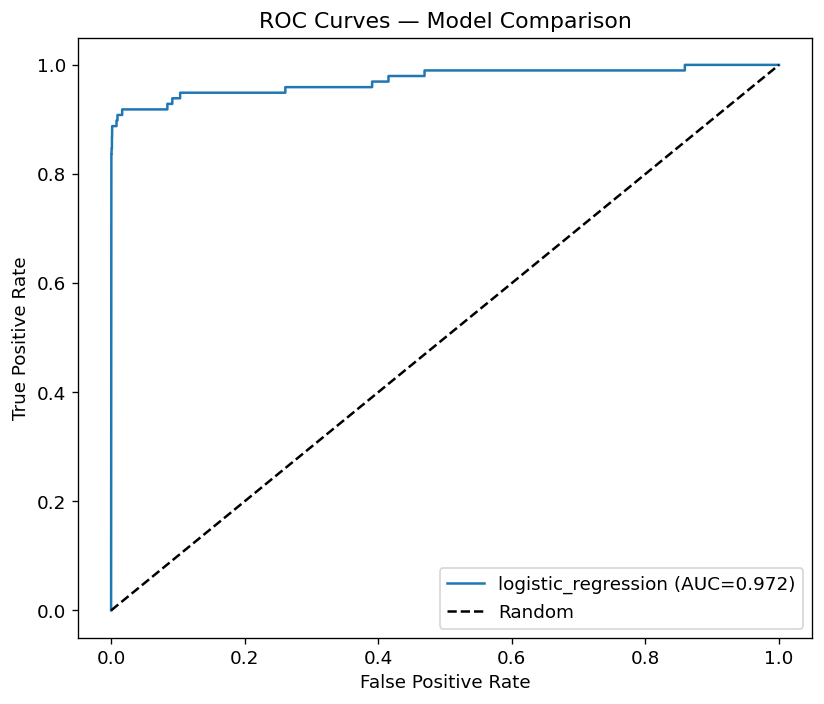

Inside pr curve
Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/pr_curves/auprc_comparison_logistic_regression.png


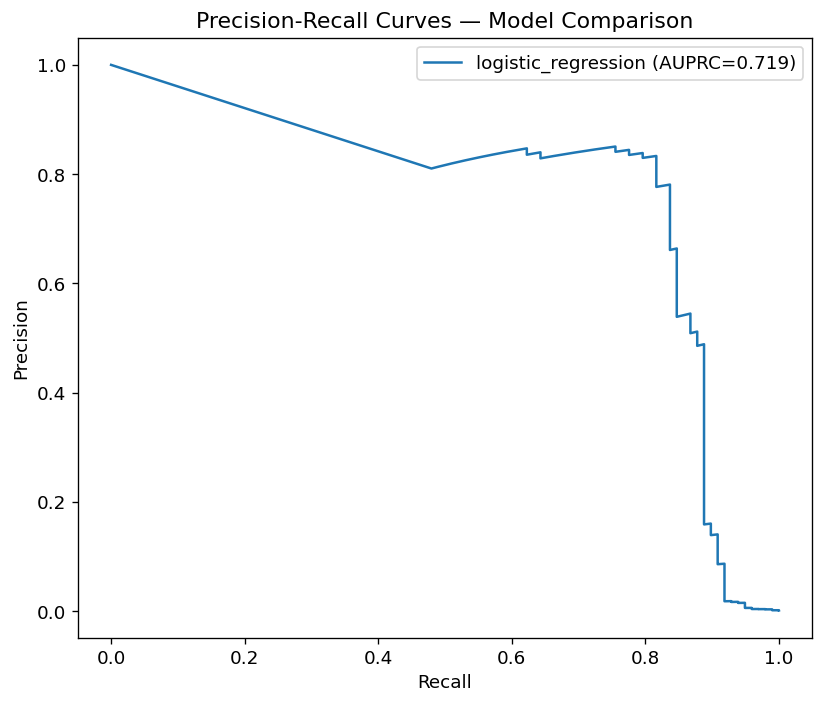

In [29]:
plot_roc_curves([result])
plot_pr_curves([result])